In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

from wordcloud import WordCloud

In [13]:
df=pd.read_csv("bigdatamart_Train.csv")
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [14]:
df.shape

(8523, 12)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [16]:
df.isnull().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

In [17]:
df.Item_Fat_Content.unique()

array(['Low Fat', 'Regular', 'low fat', 'LF', 'reg'], dtype=object)

<Axes: xlabel='Item_Fat_Content', ylabel='count'>

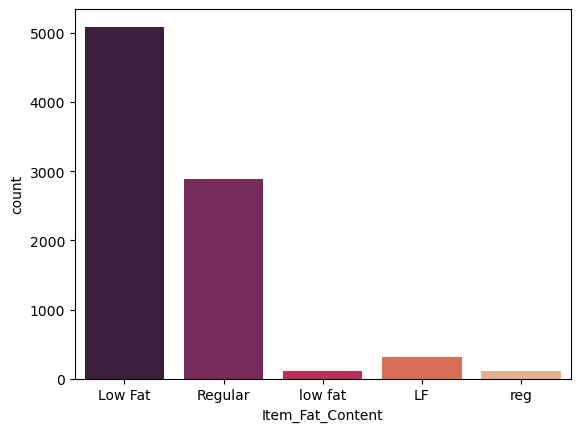

In [18]:
sns.countplot(x=df.Item_Fat_Content,palette='rocket')

In [19]:
df.Item_Fat_Content=df.Item_Fat_Content.replace({"LF":"Low Fat","low fat":"Low Fat","reg":"Regular"})

In [20]:
df.Item_Fat_Content.unique()

array(['Low Fat', 'Regular'], dtype=object)

In [22]:
df.Item_Fat_Content.value_counts()

Item_Fat_Content
Low Fat    5517
Regular    3006
Name: count, dtype: int64

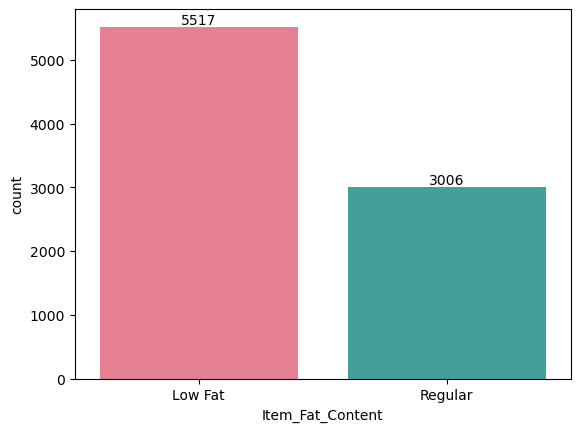

In [28]:
label=sns.countplot(x="Item_Fat_Content",data=df,palette='husl')
for i in label.containers:
    label.bar_label(i)

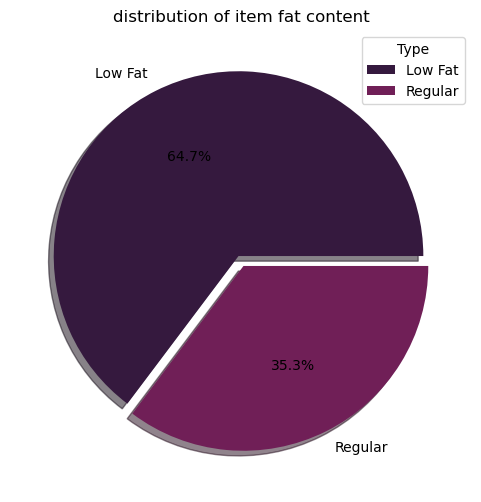

In [34]:
plt.figure(figsize=(6,6))
sns.set_palette("rocket")
plt.pie(df.Item_Fat_Content.value_counts().values,
        labels=df.Item_Fat_Content.value_counts().index,
        explode=(0.03,0.03),
        autopct='%1.1f%%',
       shadow=True)
plt.title('distribution of item fat content')
plt.legend(title="Type",loc="upper right")
plt.show()

In [35]:
df.Item_Type.value_counts()

Item_Type
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64
Name: count, dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

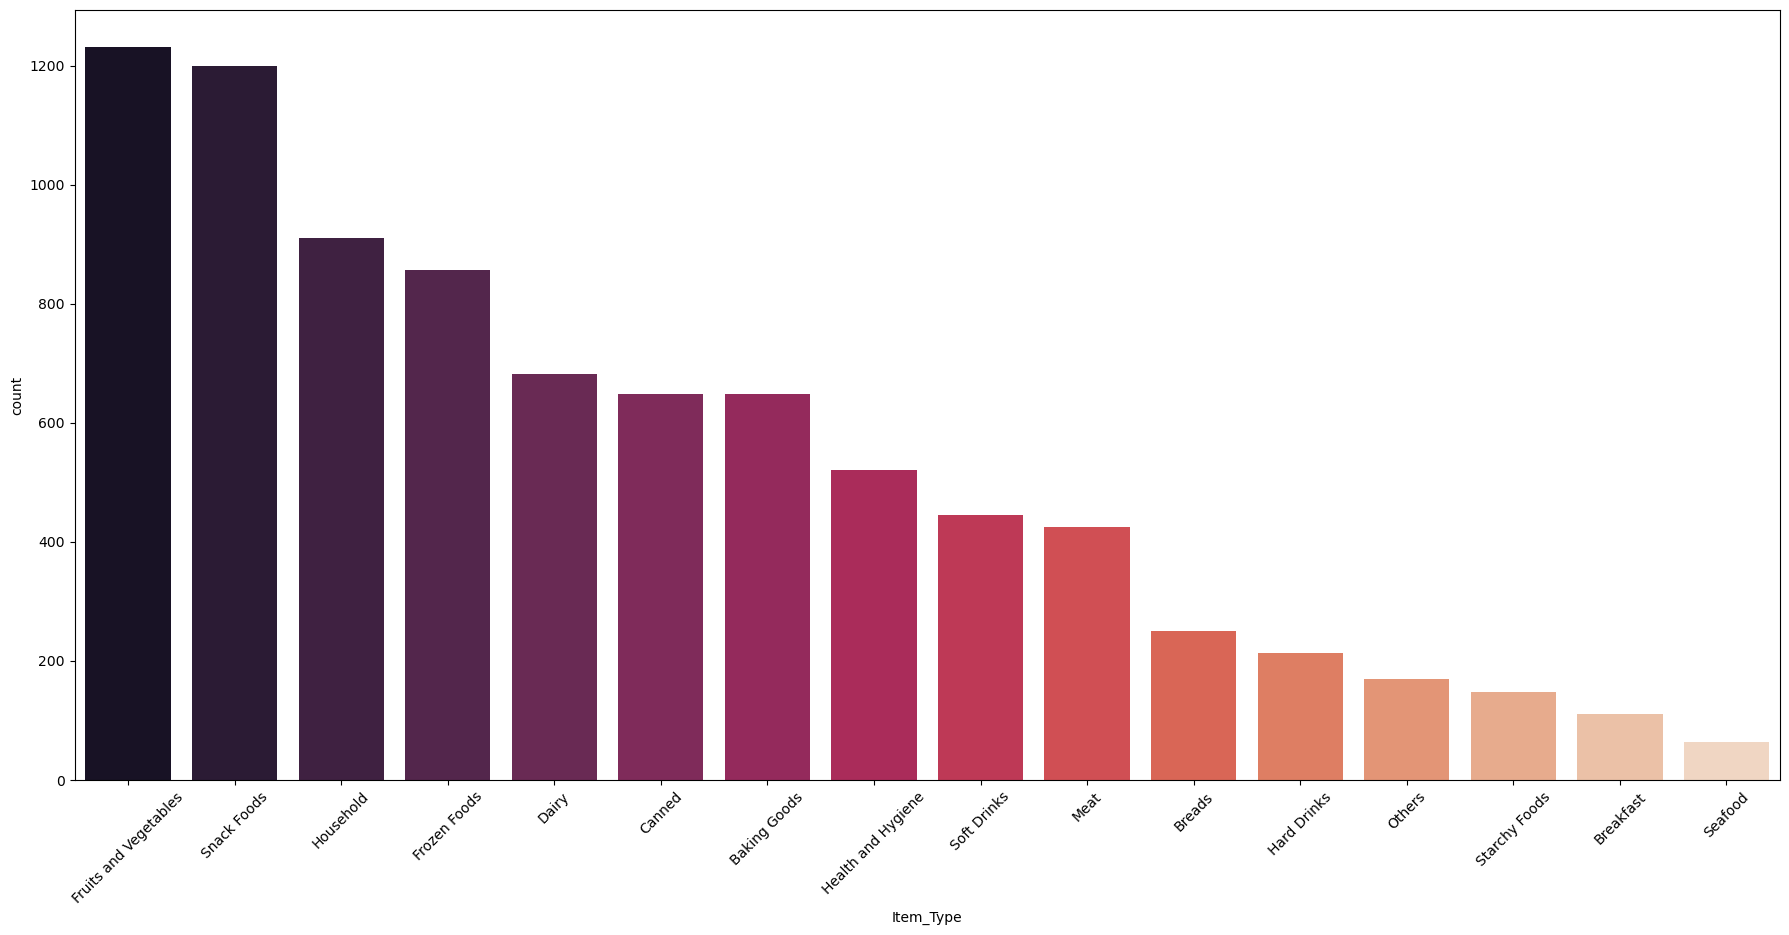

In [48]:
plt.figure(figsize=(22,10))
sns.countplot(x=df.Item_Type,
              order=df.Item_Type.value_counts().index,
              palette="rocket")
plt.xticks(rotation=45)
plt.show

In [40]:
df.Item_Identifier.unique()

array(['FDA15', 'DRC01', 'FDN15', ..., 'NCF55', 'NCW30', 'NCW05'],
      dtype=object)

In [42]:
df['Item_Type_Combined']=df.Item_Identifier.apply(lambda x:x[:2])
df['Item_Type_Combined']=df['Item_Type_Combined'].map({'FD':'Food',
                                                      'NC':'Non-Consumable',
                                                      'DR':'Drinks'})
df['Item_Type_Combined'].value_counts()

Item_Type_Combined
Food              6125
Non-Consumable    1599
Drinks             799
Name: count, dtype: int64

In [52]:
df.loc[df.Item_Type_Combined=='Non-Consumable']

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Item_Type_Combined
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052,Non-Consumable
16,NCB42,11.80,Low Fat,0.008596,Health and Hygiene,115.3492,OUT018,2009,Medium,Tier 3,Supermarket Type2,1621.8888,Non-Consumable
22,NCB30,14.60,Low Fat,0.025698,Household,196.5084,OUT035,2004,Small,Tier 2,Supermarket Type1,1587.2672,Non-Consumable
25,NCD06,13.00,Low Fat,0.099887,Household,45.9060,OUT017,2007,NaN,Tier 2,Supermarket Type1,838.9080,Non-Consumable
31,NCS17,18.60,Low Fat,0.080829,Health and Hygiene,96.4436,OUT018,2009,Medium,Tier 3,Supermarket Type2,2741.7644,Non-Consumable
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8500,NCQ42,20.35,Low Fat,0.000000,Household,125.1678,OUT017,2007,NaN,Tier 2,Supermarket Type1,1907.5170,Non-Consumable
8502,NCH43,8.42,Low Fat,0.070712,Household,216.4192,OUT045,2002,NaN,Tier 2,Supermarket Type1,3020.0688,Non-Consumable
8504,NCN18,NaN,Low Fat,0.124111,Household,111.7544,OUT027,1985,Medium,Tier 3,Supermarket Type3,4138.6128,Non-Consumable
8516,NCJ19,18.60,Low Fat,0.118661,Others,58.7588,OUT018,2009,Medium,Tier 3,Supermarket Type2,858.8820,Non-Consumable


In [54]:
df.loc[df.Item_Type_Combined=='Non-Consumable','Item_Fat_Content']

4       Low Fat
16      Low Fat
22      Low Fat
25      Low Fat
31      Low Fat
         ...   
8500    Low Fat
8502    Low Fat
8504    Low Fat
8516    Low Fat
8520    Low Fat
Name: Item_Fat_Content, Length: 1599, dtype: object

In [55]:
df.loc[df.Item_Type_Combined=='Non-Consumable','Item_Fat_Content']='Non-Edible'
df.Item_Fat_Content.value_counts()

Item_Fat_Content
Low Fat       3918
Regular       3006
Non-Edible    1599
Name: count, dtype: int64

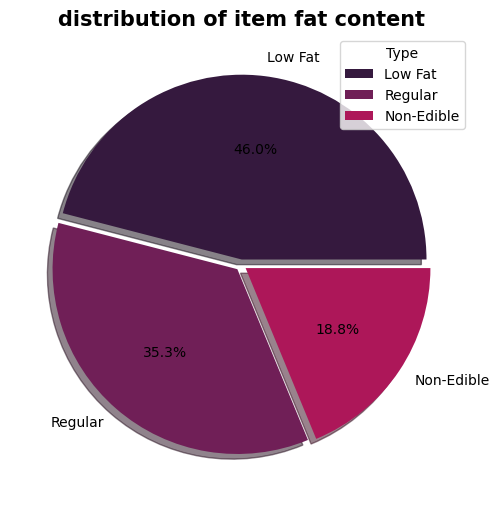

In [58]:
plt.figure(figsize=(6,6))
sns.set_palette("rocket")
plt.pie(df.Item_Fat_Content.value_counts().values,
        labels=df.Item_Fat_Content.value_counts().index,
        explode=(0.03,0.03,0.03),
        autopct='%1.1f%%',
       shadow=True)
plt.title('distribution of item fat content',
         fontsize=15,
         fontweight='bold')
plt.legend(title="Type",loc="upper right")
plt.show()

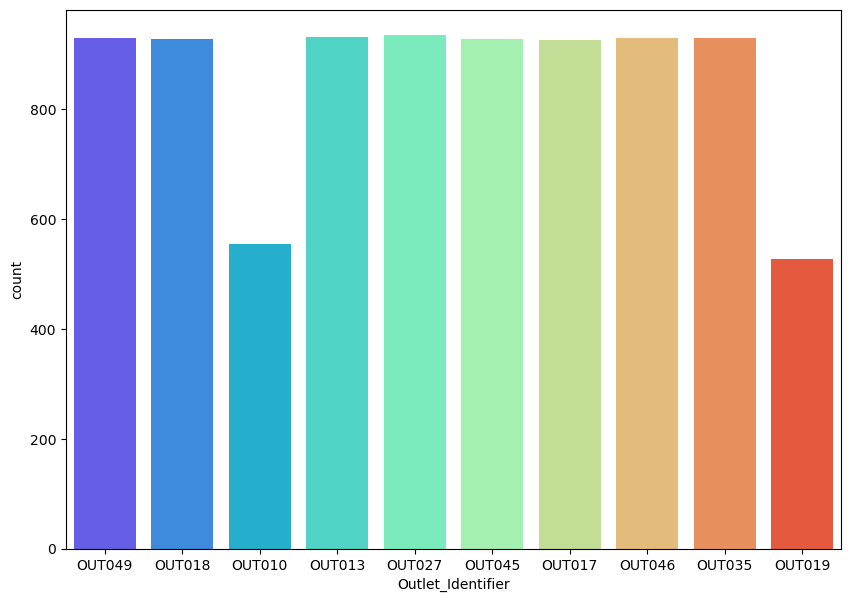

In [61]:
plt.figure(figsize=(10,7))
sns.countplot(x=df.Outlet_Identifier,palette='rainbow')
plt.show()

In [64]:
df.Outlet_Type.value_counts()

Outlet_Type
Supermarket Type1    5577
Grocery Store        1083
Supermarket Type3     935
Supermarket Type2     928
Name: count, dtype: int64

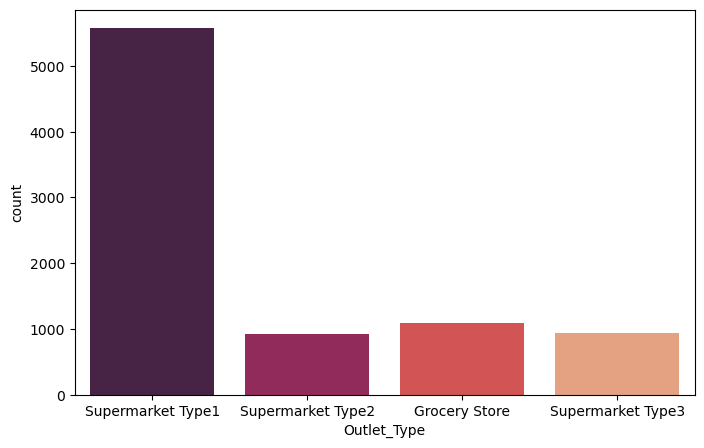

In [65]:
plt.figure(figsize=(8,5))
sns.countplot(x=df.Outlet_Type,palette="rocket")
plt.show()

In [67]:
df.pivot_table(values="Item_Outlet_Sales",index="Outlet_Type")

,Item_Outlet_Sales
Outlet_Type,
Grocery Store,339.828500
Supermarket Type1,2316.181148
Supermarket Type2,1995.498739
Supermarket Type3,3694.038558


In [69]:
df.groupby("Outlet_Type")["Item_Outlet_Sales"].mean()

Outlet_Type
Grocery Store         339.828500
Supermarket Type1    2316.181148
Supermarket Type2    1995.498739
Supermarket Type3    3694.038558
Name: Item_Outlet_Sales, dtype: float64

In [70]:
df.Outlet_Location_Type.value_counts()

Outlet_Location_Type
Tier 3    3350
Tier 2    2785
Tier 1    2388
Name: count, dtype: int64

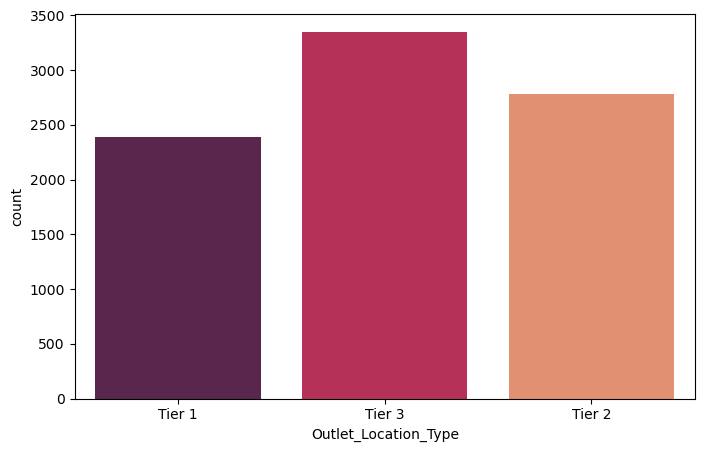

In [71]:
plt.figure(figsize=(8,5))
sns.countplot(x=df.Outlet_Location_Type,palette="rocket")
plt.show()

In [72]:
df.Item_Weight.isnull().sum()

np.int64(1463)

In [74]:
df.groupby('Item_Type')['Item_Weight'].value_counts(dropna=False)

Item_Type      Item_Weight
Baking Goods   NaN            112
               9.800           15
               15.500          14
               17.750          14
               9.195           12
                             ... 
Starchy Foods  10.500           3
               14.000           3
               20.500           3
               21.200           3
               18.000           1
Name: count, Length: 1197, dtype: int64